## Setup

In [ ]:
# Create the virtual environment
# python -m venv nlp_report

# Activate the environment (Mac/Linux)
# source nlp_report/bin/activate

# Install the Jupyter kernel bridge
# pip install ipykernel

# Register the environment as a Jupyter Kernel
# python -m ipykernel install --user --name=nlp_report --display-name="NLP Propaganda Report"

In [27]:
%pip -q install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip freeze > requirements.txt

## Dataset

### Reading Data

In [100]:
import pandas as pd

# Define your file path
file_path = './propaganda_dataset_v2/propaganda_train.tsv'

# Read the TSV file into a pandas DataFrame
# The sep='\t' argument is crucial here as it tells pandas to split columns by tabs, not commas
df = pd.read_csv(file_path, sep='\t')

# Print a quick summary of the dataframe (row count, null values, data types)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2414 entries, 0 to 2413
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   label              2414 non-null   str  
 1   tagged_in_context  2414 non-null   str  
dtypes: str(2)
memory usage: 37.8 KB


In [101]:
display(df.head())

,label,tagged_in_context
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed."
1,not_propaganda,This declassification effort <BOS> won’t make ...
2,flag_waving,The Obama administration misled the <BOS> Amer...
3,not_propaganda,“It looks like we’re capturing the demise of t...
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>"


In [103]:
for i in range(3):
    print(df['tagged_in_context'][i])

No, <BOS> he <EOS> will not be confirmed. 
This declassification effort <BOS> won’t make things any worse than they are for President Trump. <EOS> 
The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen. 


### Data Cleaning

In [104]:
import html

# Replace all types of line breaks with a space
df['tagged_in_context'] = df['tagged_in_context'].str.replace(r'[\n\r]+', ' ', regex=True)

# Strip leading/trailing whitespace that might be left over
df['tagged_in_context'] = df['tagged_in_context'].str.strip()

# Remove html Artifacts
df['tagged_in_context'] = df['tagged_in_context'].apply(html.unescape)

# Standardize Quotation Marks
def standardize_quotes(text):
    text = text.replace('“', '"').replace('”', '"')
    text = text.replace('‘', "'").replace('’', "'")
    return text

df['tagged_in_context'] = df['tagged_in_context'].apply(standardize_quotes)

# Remove non-ascii characters 
df['tagged_in_context'] = df['tagged_in_context'].str.encode('ascii', 'ignore').str.decode('ascii')

### Column Unpacking

In [105]:
import re
import pandas as pd

def extract_text_segments(text):
    text = str(text)
    match = re.search(r'^(.*?)<BOS>(.*?)<EOS>(.*?)$', text, flags=re.DOTALL)
    
    if match:
        return match.groups()
    return "", "", ""

# Apply the extraction and create the new columns
df[['left_context', 'snippet', 'right_context']] = df['tagged_in_context'].apply(
    lambda x: pd.Series(extract_text_segments(x))
)

# Recombine the three segments with a single space
df['full_sequence'] = df['left_context'] + " " + df['snippet'] + " " + df['right_context']

# Clean up any double spaces caused by empty contexts
df['full_sequence'] = df['full_sequence'].apply(lambda x: ' '.join(x.split()))

# Strip any lingering whitespace from the new segments
for col in ['left_context', 'snippet', 'right_context']:
    df[col] = df[col].str.strip()

df.head()

,label,tagged_in_context,left_context,snippet,right_context,full_sequence
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","No,",he,will not be confirmed.,"No, he will not be confirmed."
1,not_propaganda,This declassification effort <BOS> won't make ...,This declassification effort,won't make things any worse than they are for ...,,This declassification effort won't make things...
2,flag_waving,The Obama administration misled the <BOS> Amer...,The Obama administration misled the,American people,and Congress because they were desperate to ge...,The Obama administration misled the American p...
3,not_propaganda,"""It looks like we're capturing the demise of t...","""It looks like we're capturing the demise of t...",and,it's different from what well-known studies le...,"""It looks like we're capturing the demise of t..."
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>",,"Location: Westerville, Ohio",,"Location: Westerville, Ohio"


## EDA

### Class Distribution

/var/folders/q9/kmgt4jcs40qbkm14m7p96ld40000gn/T/ipykernel_34746/1738484018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


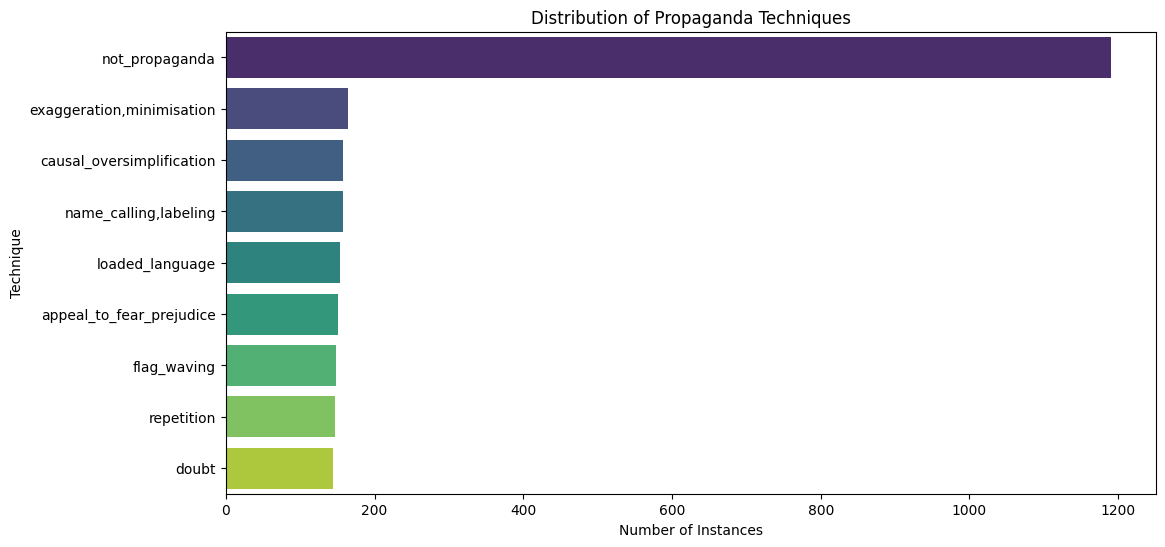

label
not_propaganda               1191
exaggeration,minimisation     164
causal_oversimplification     158
name_calling,labeling         157
loaded_language               154
appeal_to_fear_prejudice      151
flag_waving                   148
repetition                    147
doubt                         144
Name: count, dtype: int64


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Propaganda Techniques')
plt.xlabel('Number of Instances')
plt.ylabel('Technique')
plt.show()

# Print the exact counts for your report text
print(df['label'].value_counts())

### Sequence Length

#### Create Freq Columns 

Create some fields to hold the sequences lengths for each instances. We can use these counts for summary statistics

In [108]:
# Calculate snippet length (word count)
df['snippet_length'] = df['snippet'].apply(lambda x: len(str(x).split()))

# Calculate context length and total length as well for future use
df['context_length'] = (df['left_context'] + " " + df['right_context']).apply(lambda x: len(str(x).split()))
df['total_length'] = df['full_sequence'].apply(lambda x: len(str(x).split()))

#### Summary statistics for the snippet length

In [109]:
# 1. Calculate the standard aggregations
summary_stats = df.groupby('label')['snippet_length'].agg([
    'count', 'min', 'mean', 'max', 'var', 'std'
]).reset_index()

# 2. Get the 25% and 75% quartiles from describe
percentiles = df.groupby('label')['snippet_length'].describe()[['25%', '75%']].reset_index()

# 3. Merge them into a single table
summary_table = pd.merge(summary_stats, percentiles, on='label')

# 4. Round for readability
summary_table = summary_table.round(2)

# Display the final summary
display(summary_table)

,label,count,min,mean,max,var,std,25%,75%
0,appeal_to_fear_prejudice,151,1,17.30,53,137.02,11.71,8.00,26.00
1,causal_oversimplification,158,3,21.58,71,173.81,13.18,12.25,28.00
2,doubt,144,1,20.57,141,344.76,18.57,8.00,27.25
3,"exaggeration,minimisation",164,1,7.52,38,29.31,5.41,3.00,10.00
4,flag_waving,148,1,10.86,73,163.19,12.77,2.00,14.00
5,loaded_language,154,1,3.47,27,10.88,3.30,1.00,4.00
6,"name_calling,labeling",157,1,4.32,24,12.57,3.54,2.00,5.00
7,not_propaganda,1191,1,6.41,82,50.03,7.07,2.00,8.50
8,repetition,147,1,2.84,31,13.62,3.69,1.00,3.00


- Huge disparity in mean lengths for different categories.
    - repetition (2.84), loaded language (3.57) 
    - causal_oversimplification (21.58), doubt (20.57)
    - it will be interested to see the eval matrix between these categories with similar mean lengths
    - short mean averages, and snippets in general, play into the hypothesis 1, i.e. the power is likely to be in the words themsevles.

In [110]:
# 1. Get the total count of instances for every label
total_counts = df['label'].value_counts()

# 2. Get the count of 1-word snippets for every label
one_word_counts = df[df['snippet_length'] == 1]['label'].value_counts()

# 3. Combine into a single analysis DataFrame
h1_analysis = pd.DataFrame({
    'Total Instances': total_counts,
    '1-Word Snippets': one_word_counts
}).fillna(0) # Ensure labels with no 1-word snippets show as 0

# 4. Calculate the percentage
h1_analysis['Percentage (%)'] = (h1_analysis['1-Word Snippets'] / h1_analysis['Total Instances']) * 100

# 5. Sort by percentage to highlight the strongest "Lexical" categories
h1_analysis = h1_analysis.sort_values(by='Percentage (%)', ascending=False).round(2)

display(h1_analysis)

,Total Instances,1-Word Snippets,Percentage (%)
label,,,
repetition,147,69.0,46.94
loaded_language,154,43.0,27.92
not_propaganda,1191,251.0,21.07
"name_calling,labeling",157,21.0,13.38
flag_waving,148,18.0,12.16
appeal_to_fear_prejudice,151,5.0,3.31
"exaggeration,minimisation",164,3.0,1.83
doubt,144,2.0,1.39
causal_oversimplification,158,0.0,0.00


- All categories (apart from `causal_oversimplification`) contain 1 length snippets
- Percentage wise mostly have a low % is unigram snippets
- Although in Repetition they make up 47% almost half of the sample.
- Interestingly, the not_propaganda label makes up 21% of itself sample which puts it 3rd on the list of 1 length snippets. 

---

#### Summary Statistics for the Context Length

In [111]:
# 1. Calculate the standard aggregations
summary_stats = df.groupby('label')['context_length'].agg([
    'count', 'min', 'mean', 'max', 'var', 'std'
]).reset_index()

# 4. Round for readability
summary_stats = summary_stats.round(2)

# Display the final summary
display(summary_stats)

,label,count,min,mean,max,var,std
0,appeal_to_fear_prejudice,151,0,18.11,600,2912.27,53.97
1,causal_oversimplification,158,0,12.22,93,288.53,16.99
2,doubt,144,0,12.40,102,387.63,19.69
3,"exaggeration,minimisation",164,0,23.90,71,294.14,17.15
4,flag_waving,148,0,29.10,1298,11359.77,106.58
5,loaded_language,154,0,24.09,76,253.65,15.93
6,"name_calling,labeling",157,1,29.17,106,378.35,19.45
7,not_propaganda,1191,0,15.53,1209,1314.89,36.26
8,repetition,147,0,24.91,406,1259.67,35.49


Transfomers tend to have a hard limit of 512 so these enormous context sequences will be truncated. Will need to work out a way to do this careful to make sure the snippet itself is not truncated. 

In [112]:
# Count rows where context_length is greater than 512
long_context_df = df[df['context_length'] > 512]
long_context_count = len(long_context_df)

# Get a breakdown by label
long_context_labels = long_context_df['label'].value_counts()

print(f"Total instances with context > 512 words: {long_context_count}")
print("\nBreakdown by Label:")
print(long_context_labels)

Total instances with context > 512 words: 3

Breakdown by Label:
label
flag_waving                 1
not_propaganda              1
appeal_to_fear_prejudice    1
Name: count, dtype: int64


/var/folders/q9/kmgt4jcs40qbkm14m7p96ld40000gn/T/ipykernel_34746/2019744551.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='context_length', y='label', palette='flare')


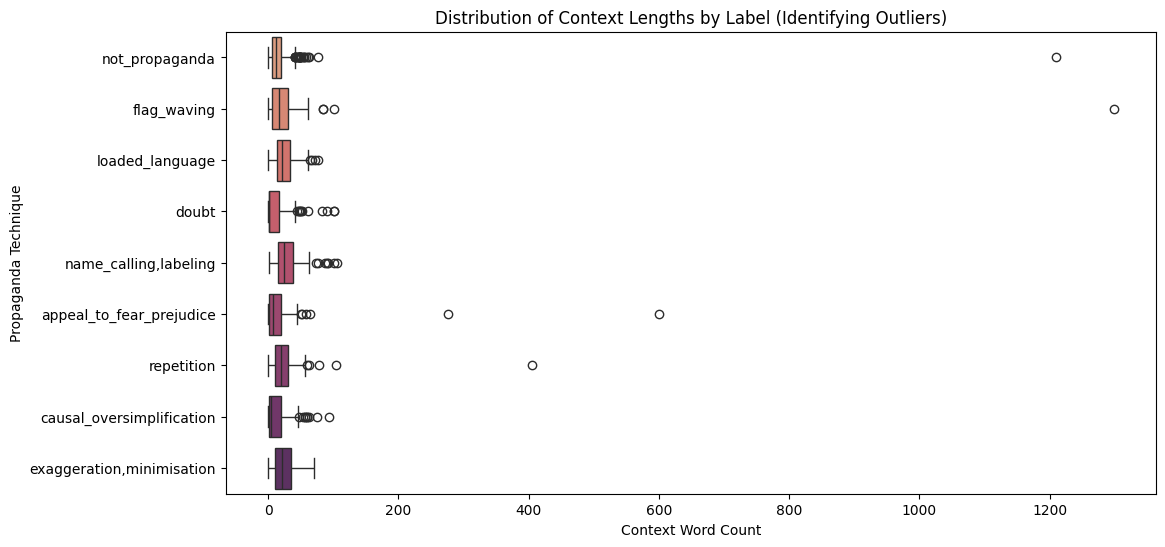

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='context_length', y='label', palette='flare')
plt.title('Distribution of Context Lengths by Label (Identifying Outliers)')
plt.xlabel('Context Word Count')
plt.ylabel('Propaganda Technique')
plt.show()

### "Lexical Trigger" Check (Top N-grams)

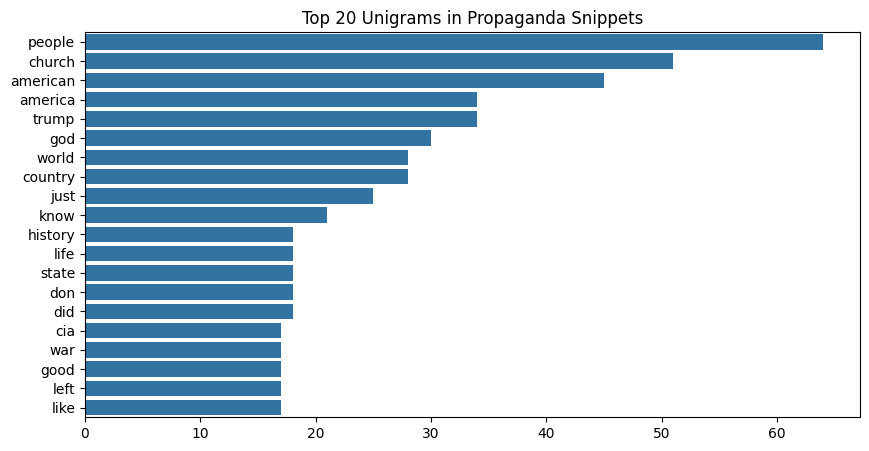

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:20]

# Plotting Top Unigrams in Propaganda Snippets
top_unigrams = get_top_ngram(df[df['label'] != 'not_propaganda']['snippet'], 1)
x, y = map(list, zip(*top_unigrams))
plt.figure(figsize=(10, 5))
sns.barplot(x=y, y=x)
plt.title('Top 20 Unigrams in Propaganda Snippets')
plt.show()